# Trabajo Semanal N°3 : 'Analisis de Fourier: FFT, desparramo, interpolacion y ventaneo'
### Alumno: Magdalena Guida

### APS - 1er cuatrimestre 2026

En el siguiente trabajo se llevara a cabo un analisis espectral, un proceso que consiste en medir, estimar y caracterizar el contenido frecuencial de las señales, con especial foco, en el efecto llamado *desparramo espectral*. Para esto, se generaron 3 senoidales con las siguientes caracteristicas: 
- Frecuencias determinadas como: $f_{0} = k_{0}*\frac{f_{s}}{N} = k_{0}*\varDelta_{f}$
- Potencia normalizada

$k_{0}$ toma los valores: {$\frac{N}{4};   \frac{N}{4} + \frac{1}{4};    \frac{N}{4} + \frac{1}{2}$}, desde donde se determinan las señales: {$ xx; xx2; xx3$}, respectivamente. Sabiendo que la potencia de una señal con *Amplitud* conocida se calcula como $P = \frac{A^{2}}{2}$, y se necesita una potencia normalizada, tal que $P = 1$, se define $A = \sqrt{2}$, para todas las señales, y se comprueba que cumpla, calculando su potencia como $np.mean(np.abs(señal ^2))$.
Luego, se calcula su *fft* para graficar su respuesta en frecuencia en unidades de dB.

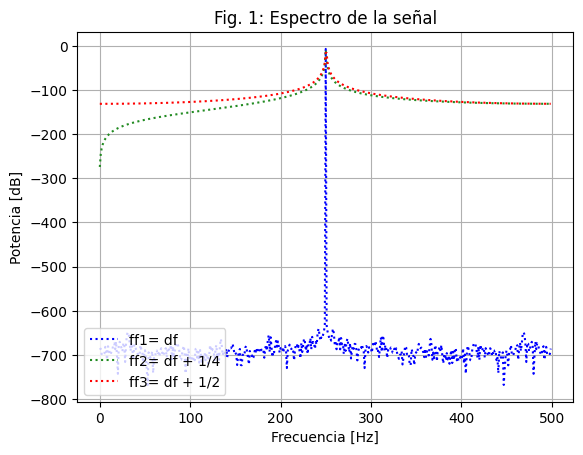

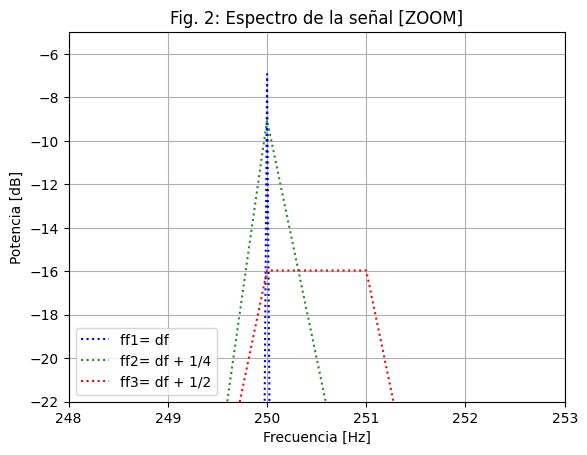

In [6]:
import numpy as np 
from numpy.fft import fft
from scipy import signal
import matplotlib.pyplot as plt

fs = 1000       #Frecuencia de muestreo
N = 1000        #Número de muestras
ts = 1 / fs     #Tiempo entre muestras correlativas
# tiempo total de muestreo = N*ts = N * 1/fs = 1s
df = fs/N       #Resolucion espectral
dc = 0          #Desplazamiento vertical [V]  
ph = 0          #FASE = Desplazamiento horizontal [rad]
ff = 0          #Frecuencia de señal

# Definicion funciónes seno
def func_sen(Vmax=1, nn=N, fs=fs, ff=ff, dc=dc, ph=ph):
    N= np.arange(nn)
    tt = N/fs
    xx = Vmax * np.sin(2 * np.pi * ff * tt + ph) + dc
    return tt, xx

#%% DEFS FUNCIONES
tt, xx = func_sen(ff = N/4 * (fs/N), Vmax = np.sqrt(2))
tt2, xx2 = func_sen(ff= (N/4 + 1/4) *  (fs/N), Vmax = np.sqrt(2) ) 
tt3, xx3 = func_sen(ff = (N/4 + 1/2) * (fs/N), Vmax = np.sqrt(2))

## Verificacion potencia unitaria 
potencia = np.mean(np.abs(xx**2))
potencia2 = np.mean(np.abs(xx2**2))
potencia3 = np.mean(np.abs(xx3**2))

## Calculo FFT
X1_fft = np.abs(1/N * np.fft.fft(xx))# / (np.sqrt(2) /2)
X2_fft = np.abs(1/N * np.fft.fft(xx2))
X3_fft = np.abs(1/N * np.fft.fft(xx3))
frecs = np.arange(N) * fs / N

#%% GRAFICO: MODULO
plt.figure()
plt.plot(frecs[:N//2], 10* np.log(X1_fft[:N//2]**2) ,':', color = 'b', label='ff1= df')
plt.plot(frecs[:N//2], 10* np.log(X2_fft[:N//2]**2), ':', color = 'forestgreen', label = 'ff2= df + 1/4')
plt.plot(frecs[:N//2], 10* np.log(X3_fft[:N//2]**2), ':', color = 'red', label = 'ff3= df + 1/2')
plt.legend(loc = 'lower left')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia [dB]')
plt.title('Fig. 1: Espectro de la señal')
plt.grid(True)

plt.figure()
plt.plot(frecs[:N//2], 10* np.log(X1_fft[:N//2]**2) ,':', color = 'b', label='ff1= df')
plt.plot(frecs[:N//2], 10* np.log(X2_fft[:N//2]**2), ':', color = 'forestgreen', label = 'ff2= df + 1/4')
plt.plot(frecs[:N//2], 10* np.log(X3_fft[:N//2]**2), ':', color = 'red', label = 'ff3= df + 1/2')
plt.legend(loc = 'lower left')
plt.xlim(248,253)
plt.ylim(-22,-5)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia [dB]')
plt.title('Fig. 2: Espectro de la señal [ZOOM]')
plt.grid(True)

Ef1 = 1/N * np.sum(X1_fft**2) 
Ef2 = 1/N * np.sum(X2_fft**2) 
Ef3 = 1/N * np.sum(X3_fft**2) 

Las Figuras 1 y 2 muestran las mismas tres densidades espectrales de potencia para las distintas frecuencias propuestas.    En el primer grafico, se puede diferenciar como el piso de *ff1* se posiciona al rededor de los $-700dB$, y presenta un pico muy empinado, que se lo puede considerar una delta en $f = 250Hz$ el valor que coincide con su frecuencia declarada $ff1=\frac{N}{4} = 250Hz$, que llega a los $0dB$, este es elcomportamiento que se esperaria para el espectro de una senoidal sin ruido con frecuencia definida. Para las senoidales *ff2* y *ff3*, se observa como el piso de ruido tiene una diferencia con el maximo alcanzado de solo $150dB$ y sus picos se notan con pendientes mas suaves, no se asemejan a una delta. La Fig. 2, muestra un acercamiento de las funciones en sus picos, la azul, mantiene la forma de delta, mientras que la verde, se la nota un ensanchamiento creciente y menor altura, y la roja no muestra un pico, sino que una constante de $1Hz$ de ancho y la menor altura. 

Estas diferencias que muestra el espectro son caracteristicas tipicas que presenta el fenomeno: *Desparramo Espectral*: la energia que deberia concentrarse solo en un unico bin de frecuencia, se desparrama entre los bins vecinos. Muestra espectros con el pico principal bajo y ancho, con lobulos laterales muy cercanos a la energia de la frecuencia central. Aparece cuando las condiciones de muestreo/ discretizacion no condicen con las de la señal correctamente. La accion de seleccionar una porcion de la señal infinita $x[n]$, se puede pensar como multiplicar la señal con una ventana de longitud $N$, en este caso con una ventana cuadrada, que no representa ningun cambio, solo influye sobre la longitud de la señal y queda definido como: $\widehat{x}[n] = x[n] w_{N}[n]$. Si, no se considera que la resolucion espectral: $\varDelta_{f} = \frac{f_{s}}{N}$, sea multiplo entero de la frecuencia de la señal: $ff$, el sistema carece de la capacidad de representar la frecuencia en el espectro, como vemos para las frecs: *ff2* y *ff3*. La resolucion espectral de este sistema es: $ df = fs / N = 1000 / 10000 = 1Hz$, puede representar con exactitud toda señal de frecuencia entera. *ff2* $=250.25 Hz$ y *ff3* $=250.5Hz$, al no ser unidades enteras, exponen desparramo espectral.

Uno de las estrategias que se pueden aplicar para reducir el desparramo espectral, es el *zero-padding* o *relleno con ceros*, que consiste alargar la señal de entrada $x(t)$ con ceros antes de calcular su FFT. Es una tecnica muy simple de implementar, que no altera la informacion original, pero si mejora como se presenta en el dominio frecuencial.  
Es un metodo exclusivamente para mejorar la visualizacion, sin modificar la señal original. Se realizo el mismo analisis, agregandole un vector $9$ veces el tamaño de $N$ a cada señal, con la funcion de *Numpy* : *concat*, que conecta elementos, que deben ser de las mismas dimensiones, secuencialmente. Se las llama=   {$xz; xz2; xz3$}, tambien, se calcula su FFT y se redefine el parametro $\varDelta_{f2} $.
Se grafica su *FFT*.

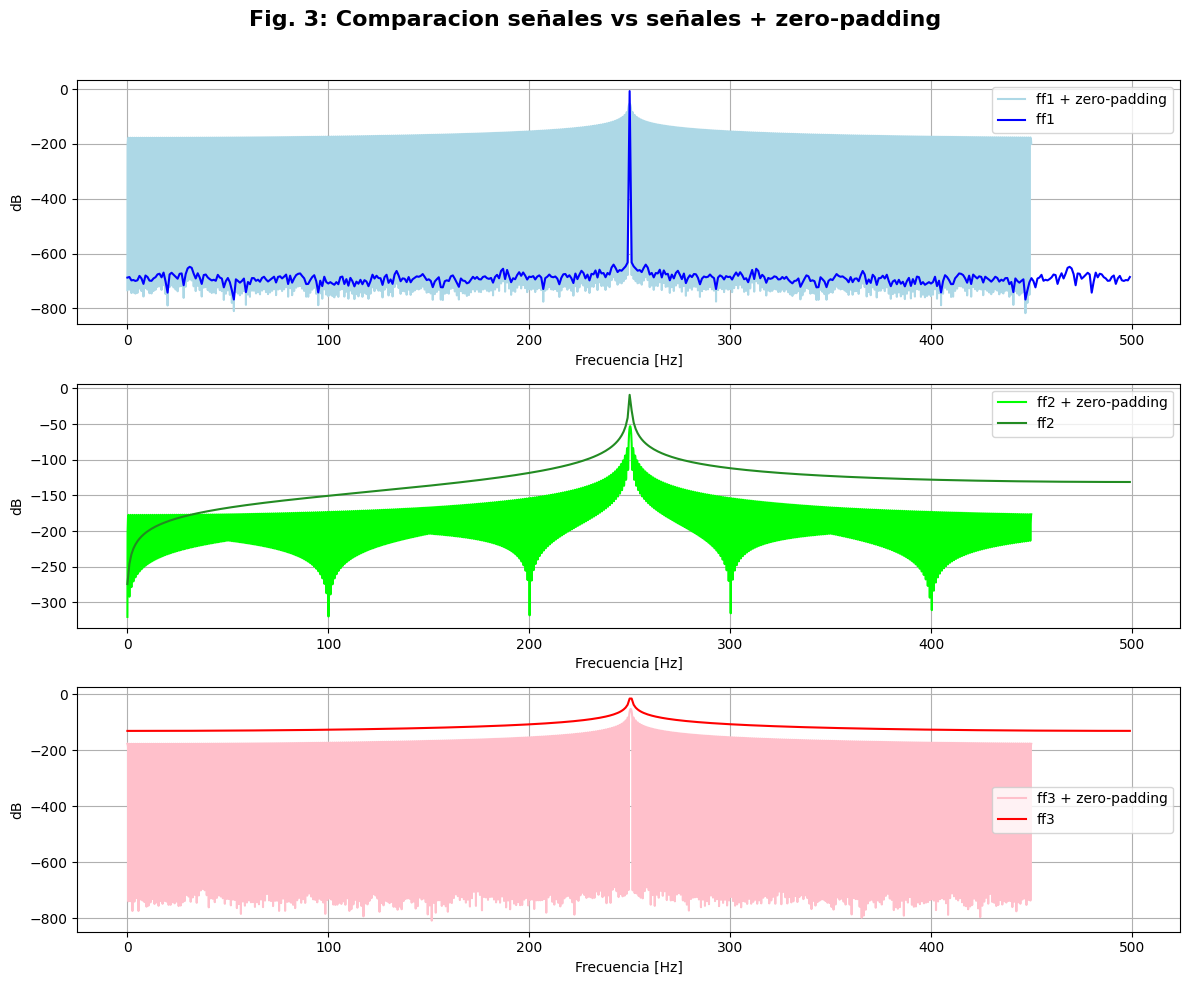

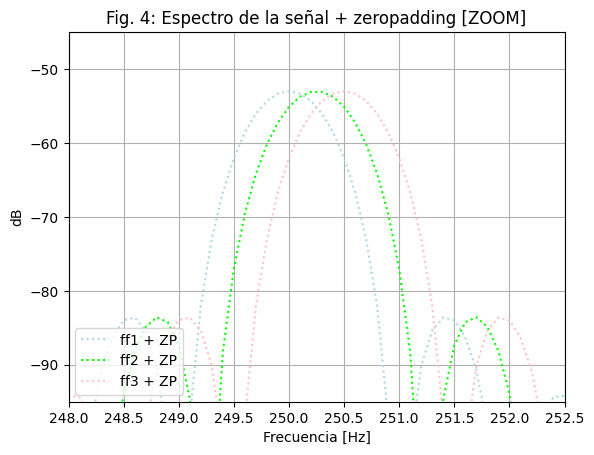

In [7]:
## APLICACION ZERO-PADDING 
df2 = fs / (9*N)

zeros = np.zeros(9*N, dtype= complex)
xz = np.concat((xx, zeros))
xz2 = np.concat((xx2,zeros))
xz3 = np.concat((xx3, zeros))

##fft + vector frecs
Xz_fft = np.abs(1/(10*N) * np.fft.fft(xz))
Xz2_fft = np.abs(1/(10*N) * np.fft.fft(xz2))
Xz3_fft = np.abs(1/(10*N) * np.fft.fft(xz3))
frecs2 = np.arange(10*N) * fs / (10*N)

#%% GrAFICOS ZERO-PADDING 
senales = [
    ("ff1 + zero-padding", frecs2[:9*N//2], 10* np.log(Xz_fft[:9*N // 2]**2), 'lightblue'),
    ("ff1 ", frecs[:N//2], 10* np.log(X1_fft[:N//2]**2), 'b'),
    ("ff2 + zero-padding", frecs2[:9*N//2], 10* np.log(Xz2_fft[:9*N // 2]**2), 'lime'),
    ("ff2", frecs[:N//2], 10* np.log(X2_fft[:N//2]**2), 'forestgreen'),
    ("ff3 + zero-padding", frecs2[:9*N//2], 10* np.log(Xz3_fft[:9*N // 2]**2), 'pink'),
    ("ff3", frecs[:N//2], 10* np.log(X3_fft[:N//2]**2), 'r'),
]

# Crear 3 subplots (uno por grupo)
fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=False)

# Graficar señales agrupadas
grupos = [(0, 1), (2, 3), (4, 5)]

for ax, (i1, i2) in zip(axs, grupos):
    for i in [i1, i2]:
        titulo, tiempo, señal, color = senales[i]
        ax.plot(tiempo, señal, color=color, label=titulo)
    ax.set(xlabel="Frecuencia [Hz]", ylabel="dB")
    ax.grid(True)
    ax.legend()
fig.suptitle("Fig. 3: Comparacion señales vs señales + zero-padding", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.figure()
plt.plot(frecs2[:9*N//2], 10* np.log(Xz_fft[:9*N//2]**2) ,':', color = 'lightblue', label='ff1 + ZP')
plt.plot(frecs2[:9*N//2], 10* np.log(Xz2_fft[:9*N//2]**2) ,':', color = 'lime', label='ff2 + ZP')
plt.plot(frecs2[:9*N//2], 10* np.log(Xz3_fft[:9*N//2]**2) ,':', color = 'pink', label='ff3 + ZP')
plt.legend(loc = 'lower left')
plt.xlim(248,252.5)
plt.ylim(-95, -45)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('dB')
plt.title('Fig. 4: Espectro de la señal + zeropadding [ZOOM]')
plt.grid(True)

La Figura 4, muestra la comparacionentre la señal CON y SIN zero-padding. La estimacion para *ff1* empeora, el piso de ruido aumenta hasta $-200dB$ y en la Fig. 4 podemos ver los lobulos laterales que alcanzan valores muy altos. La *ff2* y *ff3*, en principio tambien se podria pensar que empeoran, ya que la Fig. 3 parece presentar la misma forma, pero con sus picos alcanzando un menor valor de energia. En cambio, la Fig. 4, que presenta solo las señales con zero-padding con 'zoom' observamos como los picos no consiguen igualar la pendiente pronunciada que presenta la señal con frecuencia multiplo de la resolucion espectral, pero ahora si es posible reconocer a que frecencia corresponde cada uno, con sus valores decimales. El metodo de  zero-padding, ayudo a mejorar la visualizacion de las frecuencias, variando la resolucion espectral. Ahora, $N_{2}$, toma un valor de $N_{2} = N + 9*N = 10*N = 10000$, la resolucion espectral $\varDelta_{f2} = fs \ (10*N) = 1000 \ 10000 = 0.1Hz$. Lo que significa que en la misma distancia que antes habia 2 puntos, ahora hay 10 puntos, se aumento la resolucion espectral. Esto, se ve reflejado en todos los graficos, ya que vemos mayor suavidad los maximos, y por eso es posible reconocer la frecuencia pero la diferencia piso de ruido - pico disminuye y se ensancha el pico principal, causado por el desparramode energia.  Este metodo, es especialmente util para mejorar la visualizacion de frecuencias entre la resolucion espectral. Pero no es compatible, si se busca mejorar la calidad de la estimacion, disminuir el piso de ruido o distinguir entre frecuencias proximas. 
Como verificacion del metodo se aplico la *Identidad de Parseval*, que es un principio del analisis de señales que establece la equivalencia energetica entre el domicion temporal y frecuencial. Aplicado en la practica, se busca que la suma del cuadrado de los componenetes de la amplitud de la señal en el dominio temporal, sea igual a la suma de los cuadrados de los componenetes de su FFT normalizados. Si, ambos toman el mismo valor, o a nivel practico su resta toma un valor lo suficientemente cercano al cero, se considera  que se cumple la identidad de Parseval. Asi, se asegura que haya conservacion de energia, y que toda la informacion del dominio frecuencial es equivalente a la del dominio temporal, con respecto a la energia. Tambien, es una confirmacion de que la FFT de la señal se calculo correctamente. Su aplicacion en el codigo se hizo mediante la funcion *id_Parseval*, que calcula la energia en el dominio temporal como la suma del valor absoluto del cuadrado de todos sus componentes y le respara la energia en frecuencia calculada como la suma de su *fft* al cuadrado normalizada.

In [3]:
##Parseval
def id_Parseval(xx):
    N = len(xx)
    Et = np.sum(np.abs(xx)**2) 
    X_fft= np.abs(np.fft.fft(xx))
    Ef = 1/N * np.sum(X_fft**2) 
    verf_Pars = Et - Ef
    return verf_Pars

## PARSEVAL 
V1 = id_Parseval(xx)
V2 = id_Parseval(xx2)
V3 = id_Parseval(xx3)
V4z = id_Parseval(xz)
V5z = id_Parseval(xz2)
V6z = id_Parseval(xz3)

print(f"Id de Parseval para señal 1= {V1}")
print(f"Id de Parseval para señal 2= {V2}")
print(f"Id de Parseval para señal 3= {V3}")
print(f"Id de Parseval para señal 4= {V4z}")
print(f"Id de Parseval para señal 5= {V5z}")
print(f"Id de Parseval para señal 6= {V6z}")

Id de Parseval para señal 1= 1.1368683772161603e-13
Id de Parseval para señal 2= 2.2737367544323206e-13
Id de Parseval para señal 3= -2.2737367544323206e-13
Id de Parseval para señal 4= 0.0
Id de Parseval para señal 5= -1.1368683772161603e-13
Id de Parseval para señal 6= 1.1368683772161603e-13


Tal como se esperaba, todas los caluculos de diferencia entre la energia en el dominio temporal y frecuencial, es lo suficientemente pequeña para considerarla cero, todos los valores son de la dimension $ \approx 0.0000000000001$. Este error es numerico o computacional, se puede dar por la funcion *np.sum* elegida para sumar los valores de la energia o el redondeo en la *FFT*, no es un error teorico.


Consigna BONUS: Se desarrollo un codigo que calcula y grafica los espectros de frecuencia de distintos sistemas LTI: $y_1$: escalon de 3 muestras, $y_2$: exponenecial decreciente y $y_3$: coseno. 

C:\Users\magui\AppData\Local\Temp\ipykernel_11268\3637232065.py:43: RuntimeWarning: divide by zero encountered in log10
  plt.plot(frecsLTI[:NY//2], 20*np.log10(Y1_fft[:NY//2]))
C:\Users\magui\AppData\Local\Temp\ipykernel_11268\3637232065.py:49: RuntimeWarning: divide by zero encountered in log10
  plt.plot(frecsLTI[:NY//2], 20*np.log10(Y2_fft[:NY//2]))


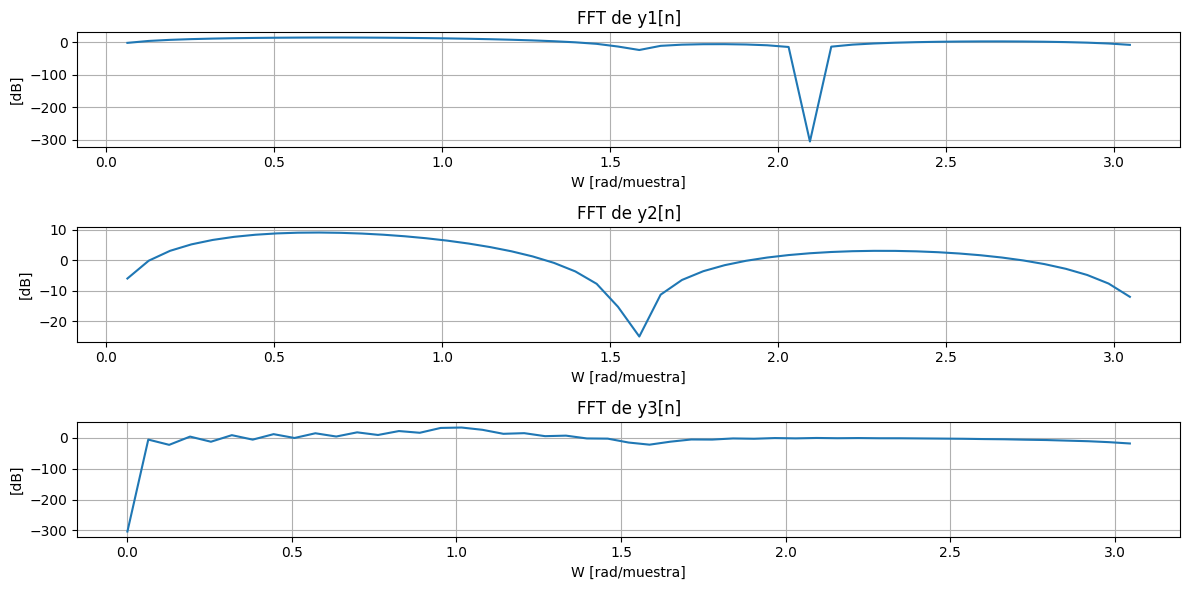

In [5]:
#%% BONUS

# Definicion del rango de n para la entrada
n = np.arange(-10, 40)
# Función escalón
u = lambda x: np.heaviside(x, 1)
W0 = 1
Ts = 1

# Entrada: x[n] 
x1 = u(n+1) - u(n-2)
x2 = (1/2)**n * u(n)
x3 = np.cos(W0 * n * Ts)

# Definicion del rango de n para h[n]
m = np.arange(0, 50)

# Delta discreta
def delta(k):
    return np.array([1 if i == 0 else 0 for i in k])
# Respuesta impulsiva: h[n] = δ[n] - δ[n-4]
h = delta(m) - delta(m-4)

# Convolución: y[n] = x[n] * h[n]
y1 = np.convolve(x1, h)
y2 = np.convolve(x2, h)
y3 = np.convolve(x3, h)

# Nuevo eje temporal para la salida
ny = np.arange(n[0] + m[0], n[-1] + m[-1] + 1)
NY = len(ny)

#Calculo FFT
Y1_fft = np.abs(np.fft.fft(y1)) 
Y2_fft = np.abs(np.fft.fft(y2))
Y3_fft = np.abs(np.fft.fft(y3))
frecsLTI = np.arange(NY) * (2* np.pi) / NY

#%% GRAFS
plt.figure(figsize=(12,6))
plt.subplot(3,1,1)
plt.plot(frecsLTI[:NY//2], 20*np.log10(Y1_fft[:NY//2]))
plt.title("FFT de y1[n]")
plt.xlabel("W [rad/muestra]")
plt.ylabel("[dB]")
plt.grid(True)
plt.subplot(3,1,2)
plt.plot(frecsLTI[:NY//2], 20*np.log10(Y2_fft[:NY//2]))
plt.title("FFT de y2[n]")
plt.xlabel("W [rad/muestra]")
plt.ylabel("[dB]")
plt.grid(True)
plt.subplot(3,1,3)
plt.plot(frecsLTI[:NY//2], 20*np.log10(Y3_fft[:NY//2]))
plt.title("FFT de y3[n]")
plt.xlabel("W [rad/muestra]")
plt.ylabel("[dB]")
plt.grid(True)
plt.tight_layout()
plt.show()

Este trabajo consistio en analizar tres señales senoidales para estudiar el fenomeno de *desparramo espectral*. Se describio su significado, su apariencia en el espectro, la razon por la que sucede y se probo como solucion el metodo de *zero-padding*. Que ayudo a mejorar la resolucion espectral sin alterar el contenido original, lo que permitio visualizar con mayor detalle las señales. Se discutio la aplicacion del metodo, sus beneficios y obstaculos y en que casos es conveniente aplicarlo. Finalmente, se verifico la *Identidad de Parseval*, confirmando la conservacion de energia entre los dominios temporales y frecuenciales, con errores numericos despreciables.